HARI PAVAN YADAV AMB2080

In [14]:
# !pip install tensorflow

# Python (version 3.8–3.11 recommended)
#TensorFlow → like driving an automatic car 
#PyTorch → like driving a manual car 


In [15]:
# better practise  split the dataset into 3 parts
# when we have our own dataset then we use train_test_split from sklearn 

# X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3)
# X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5)

In [16]:
import tensorflow as tf

# Step 1: Load dataset
mnist = tf.keras.datasets.mnist
#(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [17]:
print("Train images shape:", X_train.shape)  # (60000, 28, 28)
print("Train labels shape:", y_train.shape)  # (60000,)
print("Test images shape:", X_test.shape)    # (10000, 28, 28)
print("Test labels shape:", y_test.shape)    # (10000,)

# 60,000 training images
# 10,000 test images
# Each image is 28×28 pixels (grayscale)
# Labels are numbers 0–9

Train images shape: (60000, 28, 28)
Train labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


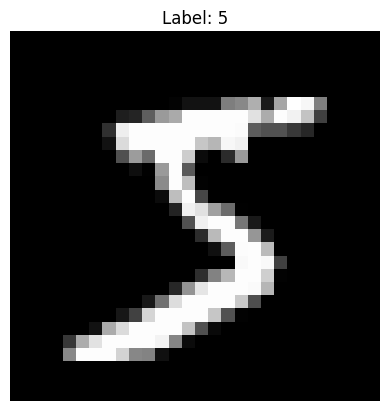

In [18]:
import matplotlib.pyplot as plt
# Plot first image
plt.imshow(X_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")  # show the label
plt.axis('off')
plt.show()

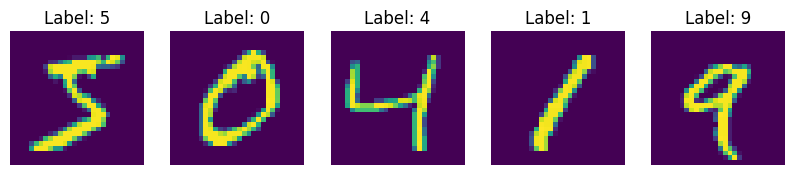

In [19]:
#Show First 5 Images With Labels
plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_train[i])
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

In [20]:
# Step 2: Normalize values (0 to 1)
train_images = X_train / 255.0
test_images = X_test / 255.0

In [ ]:
# Step 3: Add channel dimension (important for CNN)
# Your original MNIST images have shape: (60000, 28, 28)
#A CNN (Conv2D) expects 4D input like: (batch_size, height, width, channels)
# A channel represents a layer of information in an image.
train_images = train_images.reshape((60000, 28, 28, 1))
test_images = test_images.reshape((10000, 28, 28, 1))

In [22]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(16, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [24]:
# Step 5: Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Step 6: Train model
model.fit(train_images, y_train, epochs=3)

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8754 - loss: 0.4494
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9748 - loss: 0.0875
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9830 - loss: 0.0583


In [25]:
# Step 7: Test model
test_loss, test_acc = model.evaluate(test_images, y_test)
print("Accuracy:", test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9716 - loss: 0.0840
Accuracy: 0.978600025177002


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Original Label: 3
Predicted Label: 3


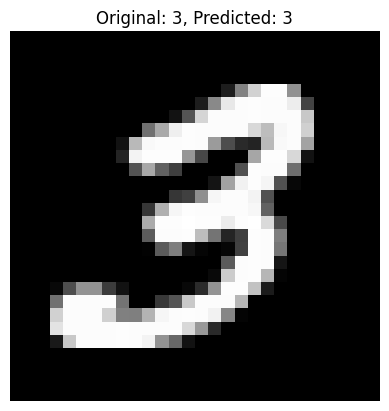

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Pick a random index
index = np.random.randint(0, len(test_images))

# Get image and label
sample_image = test_images[index]
true_label = y_test[index]

# Expand dimensions for model input
sample_image_input = np.expand_dims(sample_image, axis=0)

# Predict
prediction = model.predict(sample_image_input)    # gives probability from 0 to 9
predicted_label = np.argmax(prediction)           # gives the index of highest probability

# Print results
print("Original Label:", true_label)
print("Predicted Label:", predicted_label)

# Show the image
plt.imshow(sample_image.squeeze(), cmap='gray')
plt.title(f"Original: {true_label}, Predicted: {predicted_label}")
plt.axis('off')
plt.show()

In [ ]:
prediction = model.predict(sample_image_input)

You don’t get a single number.
You get probabilities for all 10 digits (0–9).
prediction = [[0.01, 0.02, 0.05, 0.10, 0.03, 0.75, 0.01, 0.01, 0.01, 0.01]]
                 0    1     2     3     4     5     6     7     8     9
Probability it's 5 → 0.75 ✅ (highest)

argmax gives the index of the highest value

In [30]:
# Step 4: Build CNN model

model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),   #convolution layer 2
    tf.keras.layers.MaxPooling2D(2,2),   #pooling layer 2

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Step 5: Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Step 6: Train model
model.fit(train_images, y_train, epochs=3)
#print(model.summary())

# Step 7: Test model
test_loss, test_acc = model.evaluate(test_images, y_test)
print("Accuracy:", test_acc)


Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8795 - loss: 0.4175
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - accuracy: 0.9798 - loss: 0.0664
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9848 - loss: 0.0480
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9827 - loss: 0.0491
Accuracy: 0.9858999848365784
